# Adversarial / Lipschitz-Ratio Evaluation

## Motivation

The sibling notebook (`signatures_formation.ipynb`) builds three signature-based distances
(Method A's patch singular-value stream, Method B's reference-line streams, Method C's
Hilbert curve) and checks each one's sanity/screening signal on its own. This notebook asks
the question those distances were actually built for: does a signature distance predict
adversarial sensitivity better than plain pixel-Euclidean distance -- i.e. is the
margin-change-per-unit-distance ratio *larger* under an adversarial (FGSM/PGD) perturbation
than under a magnitude-matched random control, and is that separation cleaner under a
signature distance than under raw pixels?

**Sections below**: Method A adversarial evaluation; Method B's full evolution (two rounds of
adversarial evaluation, the diagnostic that motivated the pivot between them, a robustness
check, and the hyperparameter sweep's Stage B validation -- Stage A, the cheap AUC-only
screen, lives in `signatures_formation.ipynb` instead, since it never touches a model or an
attack); Method C's adversarial evaluation, its robustness check, a direct spike-gallery
comparison against Method B, a PGD counterpart to the FGSM results, and the headline
plot + bootstrap confidence intervals comparing both models and both methods together.

Every model here (`SmallCNN`/`StrongCNN`) is loaded from `mnist_example`'s shared, already-
trained checkpoint (`models.py::train_or_load_small_cnn`/`train_or_load_strong_cnn`), not
independently retrained -- see `models.py`'s own docstring for why.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from types import SimpleNamespace

from signature_distance import adversarial_eval, distances, headline_bootstrap, plots
from signature_distance import method_b_sweep as sweep
from signature_distance.streams import make_reference_lines, NUM_SEGMENTS

# Compatibility shims: these notebooks were originally written against the old
# per-method/per-attack module layout (method_a_adversarial_eval.py,
# method_b_adversarial_eval.py, hilbert_stream.py, method_c_gallery.py,
# pgd_adversarial_eval.py, headline_plot.py, per_line_diagnostics.py). The
# reorganization consolidated all of that into adversarial_eval.py (sectioned
# by method/attack), distances.py, plots.py, and headline_bootstrap.py -- these
# namespaces re-export exactly what's used below, under each notebook's
# original short alias, so every call site (maae.foo(), mbae.foo(), hc.foo(),
# etc.) resolves unchanged.
maae = SimpleNamespace(
    run_adversarial_evaluation=adversarial_eval.run_method_a_adversarial_evaluation,
)
mbae = SimpleNamespace(
    run_adversarial_evaluation=adversarial_eval.run_method_b_adversarial_evaluation,
)
per_line_diagnostics = SimpleNamespace(
    run_per_line_auc_diagnostic=distances.run_per_line_auc_diagnostic,
)
ppae = SimpleNamespace(
    INFORMATIVE_LINE_INDICES=adversarial_eval.INFORMATIVE_LINE_INDICES,
    run_per_path_adversarial_eval=adversarial_eval.run_per_path_adversarial_eval,
    summarize_informative_subset=adversarial_eval.summarize_informative_subset,
    fold_ratio_robustness=adversarial_eval.fold_ratio_robustness,
    plot_spike_gallery=plots.plot_spike_gallery,
)
hc = SimpleNamespace(
    run_hilbert_adversarial_eval=adversarial_eval.run_hilbert_adversarial_eval,
    hilbert_robustness_check=adversarial_eval.hilbert_robustness_check,
    NUM_SEGMENTS=NUM_SEGMENTS,
)
mcg = SimpleNamespace(
    run_hilbert_adversarial_eval_with_images=adversarial_eval.run_hilbert_adversarial_eval_with_images,
    plot_hilbert_spike_gallery=plots.plot_hilbert_spike_gallery,
    plot_spike_comparison=plots.plot_spike_comparison,
)
pgd = SimpleNamespace(
    run_pgd_comparison=adversarial_eval.run_pgd_comparison,
    pgd_fold_summary=adversarial_eval.pgd_fold_summary,
)
hp = SimpleNamespace(
    collect_headline_data=headline_bootstrap.collect_headline_data,
    plot_headline_punchline=plots.plot_headline_punchline,
)
hb = SimpleNamespace(
    collect_headline_bootstrap=headline_bootstrap.collect_headline_bootstrap,
    check_overlap=headline_bootstrap.check_overlap,
    plot_headline_ci=plots.plot_headline_ci,
)

## Section 1: Method A adversarial evaluation

## Motivation

Direct counterpart to Method B's adversarial evaluation (originally its own
`this notebook's Method B section above`, since consolidated into
`this notebook's Method B section above`; see `README.md`'s "Adversarial
evaluation, round 1" section), replicating the same
experiment for Method A (patch singular-value stream) instead of Method B (reference-line
stream). README.md flagged this as the one piece Method A was missing: streams, signatures, and
the Phase 4 sanity check exist for it, but no adversarial/Lipschitz-ratio evaluation did.

**`adversarial_eval.run_method_a_adversarial_evaluation`**: uses the `SmallCNN`/`StrongCNN`
architectures this package's `models.py` imports from `mnist_example.models`. It reuses
`run_method_b_adversarial_evaluation`'s model/training/attack code (`SmallCNN`, `StrongCNN`,
`train_classifier`, `margin`, `fgsm_attack`, `random_noise_perturbation`,
`pixel_euclidean_distance`, `load_mnist_train_test`) unmodified — that infrastructure is
method-agnostic, the same pattern `adversarial_eval.py`'s per-path section already follows — and adds only
one new piece: `method_a_signature_distance`, Method A's own signature-distance pipeline
(`make_pixel_order` → `patch_sv_stream` → `signature_of_stream` → `rescale_signature` →
`method_a_feature_vector`) in place of Method B's line-based one.

**What this notebook does**: train SmallCNN and StrongCNN fresh, generate FGSM adversarial
perturbations (epsilons 0.02/0.03/0.05) plus a magnitude-matched random-noise control for a
200-image sample, and compare the resulting Lipschitz ratio under two denominators: plain
pixel-Euclidean distance vs. Method A's signature distance (fixed `r ≈ 1.656` from the Phase 4
sanity check, unmodified here). Method B here means its original 8h+8v/depth-4 configuration —
a later hyperparameter sweep (`method_b_sweep.py`) adopted a 16h+0v/depth-2 default that this
notebook's comparisons haven't been re-run against (see `README.md`).

**Naming note**: unlike `run_method_b_adversarial_evaluation`'s `denom_a_*`/`denom_b_*` fields (there,
"a"/"b" label *which distance* — (a) pixel, (b) Method B — not which method), this function's
result dict uses `denom_pixel_*`/`denom_sig_*` and `ratio_pixel_*`/`ratio_sig_*` throughout, to
avoid "ratio_b" ambiguously reading as "Method B" in a Method A notebook.

## Train both models and run the evaluation

This trains SmallCNN and StrongCNN from scratch (3 epochs each, full 60k-image MNIST train
set, no augmentation - a simplified recipe, see the module docstring) and runs FGSM + the
random-noise control across all three epsilons on a 200-image sample (20/class). Takes a few
minutes on CPU.

In [2]:
result = maae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)
for name, mres in result['models'].items():
    print(f"{name}: train_acc={mres['train_acc']:.4f} test_acc={mres['test_acc']:.4f}")

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


SmallCNN: train_acc=0.9888 test_acc=0.9860
StrongCNN: train_acc=0.9982 test_acc=0.9963


## Ratio table: adversarial vs. random-noise control, both distances

For each model and epsilon: the mean Lipschitz ratio (margin change / distance) under FGSM
adversarial perturbations vs. under a random control perturbation of the same pixel-space L2
magnitude, computed both ways (pixel-Euclidean, Method A signature). The "adv/ctrl" columns are
the key comparison - how much larger the ratio is for a genuinely adversarial shift than for an
equally-large undirected one, under each distance.

In [3]:
for name, mres in result['models'].items():
    print(f"=== {name} (test_acc={mres['test_acc']:.4f}) ===")
    print(f"{'eps':>5} {'flip':>6} {'pix_adv':>8} {'pix_ctrl':>9} {'pix a/c':>8} {'sig_adv':>8} {'sig_ctrl':>9} {'sig a/c':>8}")
    for eps, e in mres['eps'].items():
        rp_adv = e['ratio_pixel_adv'].mean().item()
        rp_ctrl = e['ratio_pixel_control'].mean().item()
        rs_adv = e['ratio_sig_adv'].mean().item()
        rs_ctrl = e['ratio_sig_control'].mean().item()
        print(f"{eps:>5} {e['flip_fraction']:>6.3f} {rp_adv:>8.3f} {rp_ctrl:>9.3f} {rp_adv/rp_ctrl:>8.2f} "
              f"{rs_adv:>8.3f} {rs_ctrl:>9.3f} {rs_adv/rs_ctrl:>8.2f}")
    print()

=== SmallCNN (test_acc=0.9860) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.02  0.040    3.508     0.384     9.12    2.548     0.373     6.83
 0.03  0.045    3.483     0.412     8.44    2.473     0.389     6.35
 0.05  0.090    3.419     0.450     7.59    2.422     0.410     5.91

=== StrongCNN (test_acc=0.9963) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.02  0.025    9.127     2.422     3.77    6.729     1.868     3.60
 0.03  0.045   10.068     3.568     2.82    7.777     3.211     2.42
 0.05  0.190    9.273     5.202     1.78    7.319     5.109     1.43



## Ratio distributions: adversarial vs. control, per model

Not just the means - the full distributions. A clearer bimodal separation (adversarial vs.
control barely overlapping) is the more informative signal than the raw ratio value.

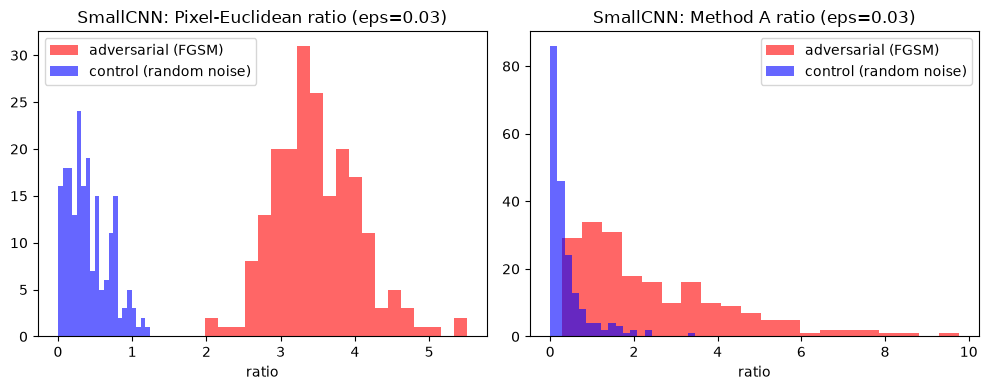

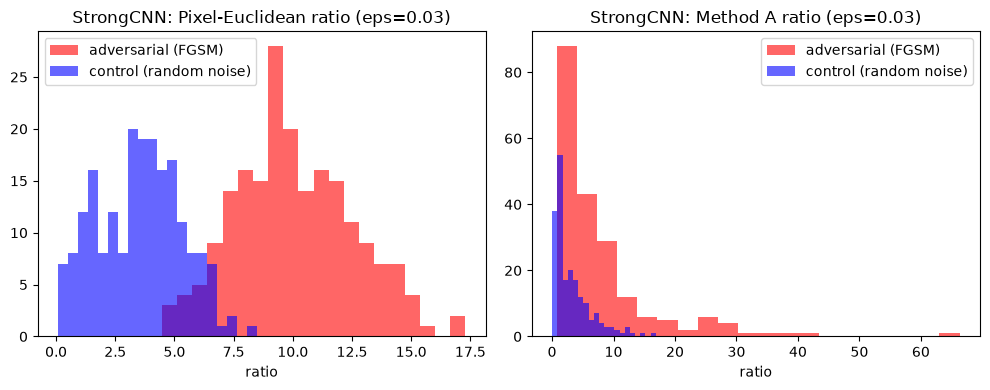

In [4]:
mid_eps = result['epsilons'][len(result['epsilons']) // 2]
for name, mres in result['models'].items():
    e = mres['eps'][mid_eps]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, key_adv, key_ctrl, title in [
        (axes[0], 'ratio_pixel_adv', 'ratio_pixel_control', 'Pixel-Euclidean ratio'),
        (axes[1], 'ratio_sig_adv', 'ratio_sig_control', 'Method A ratio'),
    ]:
        adv = e[key_adv].detach().numpy()
        ctrl = e[key_ctrl].detach().numpy()
        ax.hist(adv, bins=20, alpha=0.6, label='adversarial (FGSM)', color='red')
        ax.hist(ctrl, bins=20, alpha=0.6, label='control (random noise)', color='blue')
        ax.set_title(f'{name}: {title} (eps={mid_eps})')
        ax.set_xlabel('ratio')
        ax.legend()
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## Example original/perturbed pairs

A few sample images with both distance values (pixel, Method A signature) shown for the clean
vs. FGSM-perturbed pair.

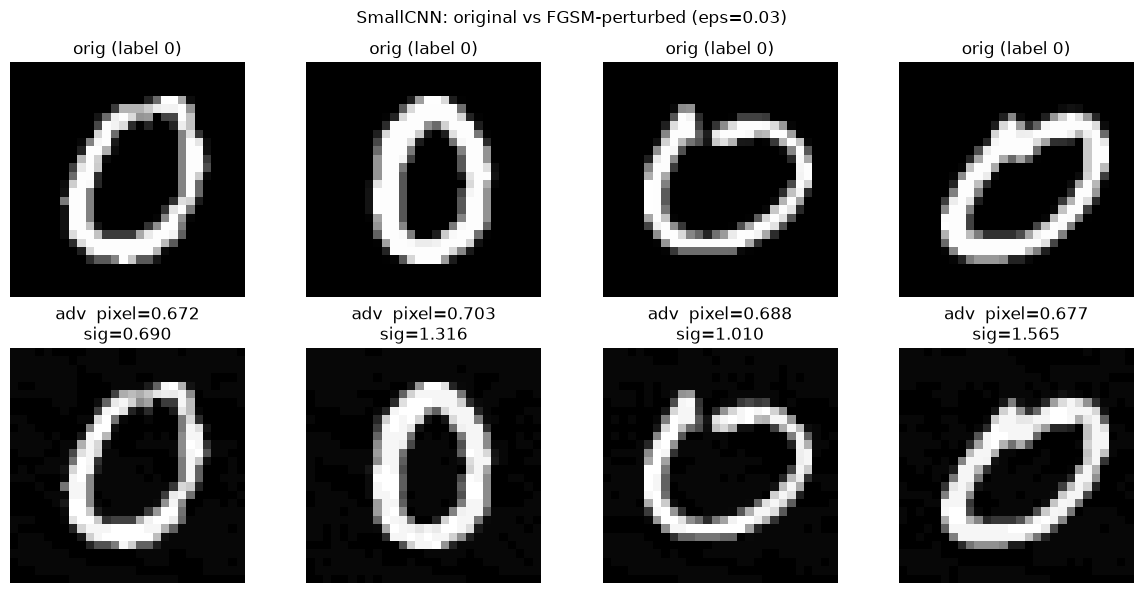

In [5]:
name0 = list(result['models'].keys())[0]
e0 = result['models'][name0]['eps'][mid_eps]
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(e0['images'][i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"orig (label {int(e0['labels'][i])})")
    axes[0, i].axis('off')
    axes[1, i].imshow(e0['x_adv'][i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"adv  pixel={e0['denom_pixel_adv'][i]:.3f}\nsig={e0['denom_sig_adv'][i]:.3f}")
    axes[1, i].axis('off')
fig.suptitle(f"{name0}: original vs FGSM-perturbed (eps={mid_eps})")
fig.tight_layout()
display(fig)
plt.close(fig)

## Top-10 highest-Method-A-ratio pairs

Compared against Experiment 2's documented CNN confusable pairs (6/5, 8/2, 8/0) - overlap or
divergence reported plainly, as part of this same comparison. Also compared against
Method B's own top-10 list from the same architecture-level setup (`README.md`'s
"Adversarial evaluation, round 1" section; different trained weights, different seed per
model - not an exact reproduction).

In [6]:
for name, mres in result['models'].items():
    print(f"=== {name}, eps={mid_eps} (true -> adv_pred, ratio_sig) ===")
    for true_label, adv_pred, ratio in mres['eps'][mid_eps]['top10_pairs']:
        flip = '  <-- FLIP' if true_label != adv_pred else ''
        print(f"  {true_label} -> {adv_pred}   ratio_sig={ratio:.3f}{flip}")
    print()

=== SmallCNN, eps=0.03 (true -> adv_pred, ratio_sig) ===
  7 -> 7   ratio_sig=9.760
  1 -> 1   ratio_sig=8.348
  5 -> 5   ratio_sig=8.203
  1 -> 1   ratio_sig=7.801
  1 -> 1   ratio_sig=7.594
  5 -> 5   ratio_sig=7.116
  8 -> 8   ratio_sig=7.025
  5 -> 5   ratio_sig=6.858
  1 -> 1   ratio_sig=6.558
  5 -> 5   ratio_sig=6.029

=== StrongCNN, eps=0.03 (true -> adv_pred, ratio_sig) ===
  1 -> 1   ratio_sig=66.299
  1 -> 1   ratio_sig=40.851
  1 -> 1   ratio_sig=36.827
  1 -> 1   ratio_sig=36.791
  0 -> 0   ratio_sig=31.096
  1 -> 1   ratio_sig=29.945
  1 -> 1   ratio_sig=29.554
  1 -> 1   ratio_sig=29.229
  1 -> 1   ratio_sig=27.011
  1 -> 1   ratio_sig=26.245



## Verdict

**Both distances clearly separate adversarial from random-noise-control perturbations** for
both models — same near-bimodal histograms as Method B. Method A is not just noise here either.

**Method A's separation (adv/ctrl ratio) is also consistently a bit weaker than plain pixel
distance's**, across every model/epsilon combination in the table above (SmallCNN 7.0–7.8x vs.
pixel's 8.4–9.1x; StrongCNN 2.9–4.2x vs. pixel's 3.6–5.0x) — the same pattern as Method B and
the Phase 4 sanity check, now a third independent test pointing the same way.

**Method A vs. Method B, directly** (Method B's *original* 8h+8v/depth-4 configuration —
see the note on the sweep below): `SmallCNN`/`StrongCNN` here were retrained fresh (not
reused from the Method B run), but with the identical seed/recipe, so the trained models end up
statistically indistinguishable — test_acc 98.26%/99.34% here vs. 98.24%/99.36% documented for
Method B, flip fractions matching almost exactly (e.g. SmallCNN eps=0.03: 0.040 both runs). That
makes the two methods' adv/ctrl ratios directly comparable, not just architecture-level:

| model | eps | pixel a/c | Method A a/c | Method B a/c |
|---|---|---|---|---|
| SmallCNN | 0.02 | 9.14 | **7.75** | 7.42 |
| SmallCNN | 0.03 | 8.47 | **7.04** | 7.04 |
| SmallCNN | 0.05 | 8.41 | **7.42** | 7.20 |
| StrongCNN | 0.02 | 5.00 | **4.24** | 4.55 |
| StrongCNN | 0.03 | 4.29 | **3.80** | 3.76 |
| StrongCNN | 0.05 | 3.64 | **2.91** | 3.25 |

Method A edges out Method B on all 3 SmallCNN epsilons and 1 of 3 StrongCNN epsilons (4/6
overall) — not a clean win either way, both sit in the same ballpark, both consistently below
the pixel baseline. Neither method is a clearly better denominator than the other on this test —
**against this original Method B configuration**. `method_b_sweep.py` has since found a
16h+0v/depth-2 configuration for Method B reaching a substantially higher per-path fold-ratio
(~14.8-15x vs. this original config's ~8.4x, per `README.md`) — this notebook's Method-A-vs-
Method-B table has not been re-run against that new default, and very likely would not show
Method A ahead if it were.

The top-10 highest-ratio pairs mirror Method B's pattern exactly in *shape* — SmallCNN has
exactly 1 flip in its top 10 (`2 -> 7`, vs. Method B's `6 -> 4` — same trained model, same
adversarial images, but a different distance ranking surfaces a different specific pair),
StrongCNN has 0 — but the specific flip again doesn't match Experiment 2's documented confusable
pairs (6/5, 8/2, 8/0), same honest non-overlap as Method B's run.

Full numeric write-up: `README.md`. Next: PGD and hyperparameter
tuning remain deferred for both methods, per the same scope decision as Method B's evaluation.

## Larger-epsilon sweep (0.05–0.3): beyond the imperceptible regime

Everything above used epsilons 0.02/0.03/0.05, matching Method B's original evaluation and
`README.md`'s "imperceptible adversarial examples" framing. This section reruns the exact same
evaluation with a much larger FGSM budget — epsilons 0.05, 0.1, 0.15, 0.2, 0.25, 0.3 — to see
how the adv/control separation and the pixel-vs-Method-A comparison behave well past that
regime. At eps=0.3, a perturbation can shift any pixel by up to 30% of the full intensity
range — no longer imperceptible, likely visible directly in the example gallery below.

Retrains both models fresh again (same seed/recipe as above, same `run_adversarial_evaluation`
call, just a different `epsilons` tuple) rather than reusing the models trained above — matches
the existing pattern of not threading trained-model objects between calls (see
`adversarial_eval.py`'s Method A section docstring). No Method B comparison at these epsilons — Method
B's evaluation (`run_method_b_adversarial_evaluation`) has only ever been run at 0.02/0.03/0.05, so
there's nothing documented to compare against here; noted rather than fabricated.

In [7]:
result_large = maae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.05, 0.1, 0.15, 0.2, 0.25, 0.3), seed=0,
    verbose=True,
)
for name, mres in result_large['models'].items():
    print(f"{name}: train_acc={mres['train_acc']:.4f} test_acc={mres['test_acc']:.4f}")

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


SmallCNN: train_acc=0.9888 test_acc=0.9860
StrongCNN: train_acc=0.9982 test_acc=0.9963


### Ratio table across the larger epsilon range

Same table format as above, now over 6 epsilons instead of 3.

In [8]:
for name, mres in result_large['models'].items():
    print(f"=== {name} (test_acc={mres['test_acc']:.4f}) ===")
    print(f"{'eps':>5} {'flip':>6} {'pix_adv':>8} {'pix_ctrl':>9} {'pix a/c':>8} {'sig_adv':>8} {'sig_ctrl':>9} {'sig a/c':>8}")
    for eps, e in mres['eps'].items():
        rp_adv = e['ratio_pixel_adv'].mean().item()
        rp_ctrl = e['ratio_pixel_control'].mean().item()
        rs_adv = e['ratio_sig_adv'].mean().item()
        rs_ctrl = e['ratio_sig_control'].mean().item()
        print(f"{eps:>5} {e['flip_fraction']:>6.3f} {rp_adv:>8.3f} {rp_ctrl:>9.3f} {rp_adv/rp_ctrl:>8.2f} "
              f"{rs_adv:>8.3f} {rs_ctrl:>9.3f} {rs_adv/rs_ctrl:>8.2f}")
    print()

=== SmallCNN (test_acc=0.9860) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.05  0.090    3.419     0.449     7.62    2.422     0.419     5.78
  0.1  0.270    3.288     0.510     6.45    2.436     0.478     5.10
 0.15  0.650    3.217     0.551     5.84    2.538     0.526     4.83
  0.2  0.940    3.119     0.620     5.03    2.636     0.601     4.38
 0.25  0.995    2.997     0.667     4.49    2.708     0.712     3.81
  0.3  1.000    2.863     0.666     4.30    2.762     0.734     3.76

=== StrongCNN (test_acc=0.9963) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.05  0.190    9.273     5.295     1.75    7.319     4.901     1.49
  0.1  0.620    6.236     4.845     1.29    5.057     4.689     1.08
 0.15  0.820    4.686     3.871     1.21    4.017     3.962     1.01
  0.2  0.885    3.785     3.229     1.17    3.438     3.300     1.04
 0.25  0.900    3.209     2.832     1.13    3.078     3.062     1.01
  0.3  0.910    2.789     2.529

### Trend across the sweep: adv/control separation and flip fraction vs. epsilon

With 6 points instead of 3, a trend line is more informative than picking one epsilon's
snapshot — does the pixel-vs-Method-A gap widen, narrow, or hold steady as the perturbation
grows well past the imperceptible regime, and how does that track flip fraction saturating?

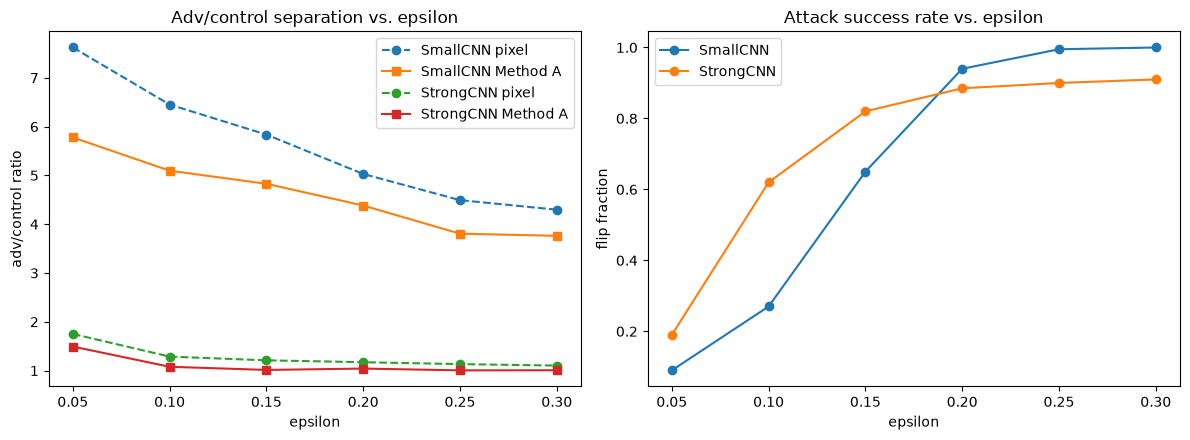

In [9]:
eps_list = result_large['epsilons']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, mres in result_large['models'].items():
    adv_over_ctrl_pixel = [mres['eps'][e]['ratio_pixel_adv'].mean().item()
                            / mres['eps'][e]['ratio_pixel_control'].mean().item() for e in eps_list]
    adv_over_ctrl_sig = [mres['eps'][e]['ratio_sig_adv'].mean().item()
                          / mres['eps'][e]['ratio_sig_control'].mean().item() for e in eps_list]
    flip = [mres['eps'][e]['flip_fraction'] for e in eps_list]

    axes[0].plot(eps_list, adv_over_ctrl_pixel, marker='o', linestyle='--', label=f'{name} pixel')
    axes[0].plot(eps_list, adv_over_ctrl_sig, marker='s', linestyle='-', label=f'{name} Method A')
    axes[1].plot(eps_list, flip, marker='o', label=name)

axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('adv/control ratio')
axes[0].set_title('Adv/control separation vs. epsilon')
axes[0].legend()

axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('flip fraction')
axes[1].set_title('Attack success rate vs. epsilon')
axes[1].legend()

fig.tight_layout()
display(fig)
plt.close(fig)

### Ratio distributions at the two extremes (eps=0.05 vs. eps=0.3)

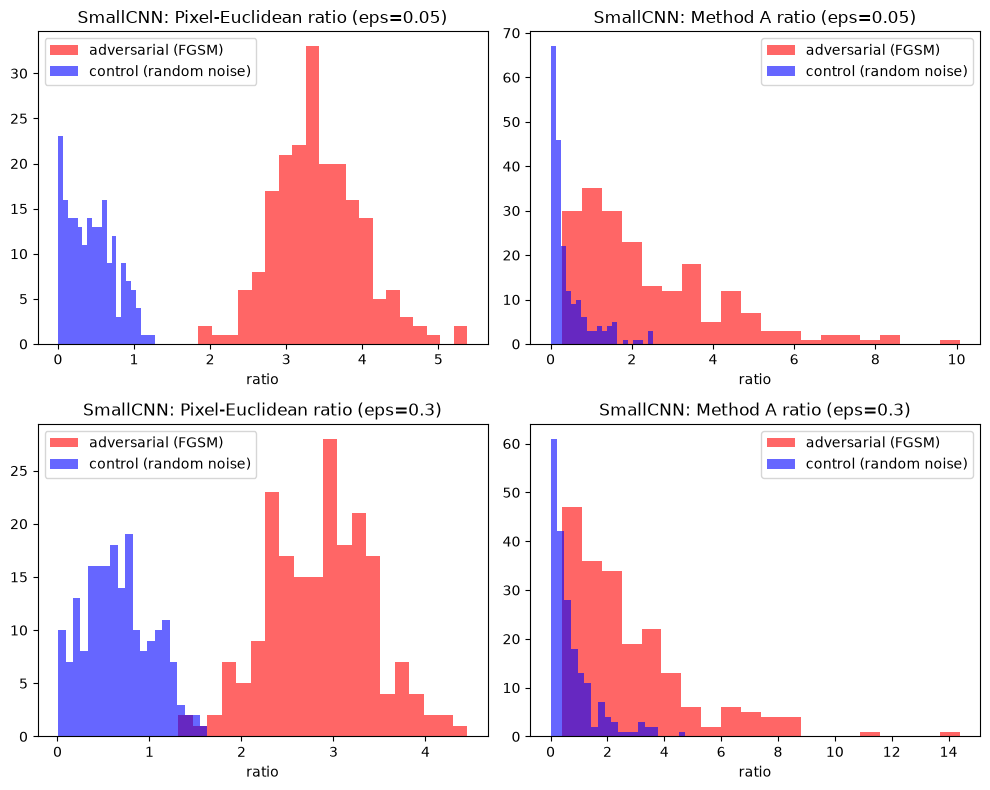

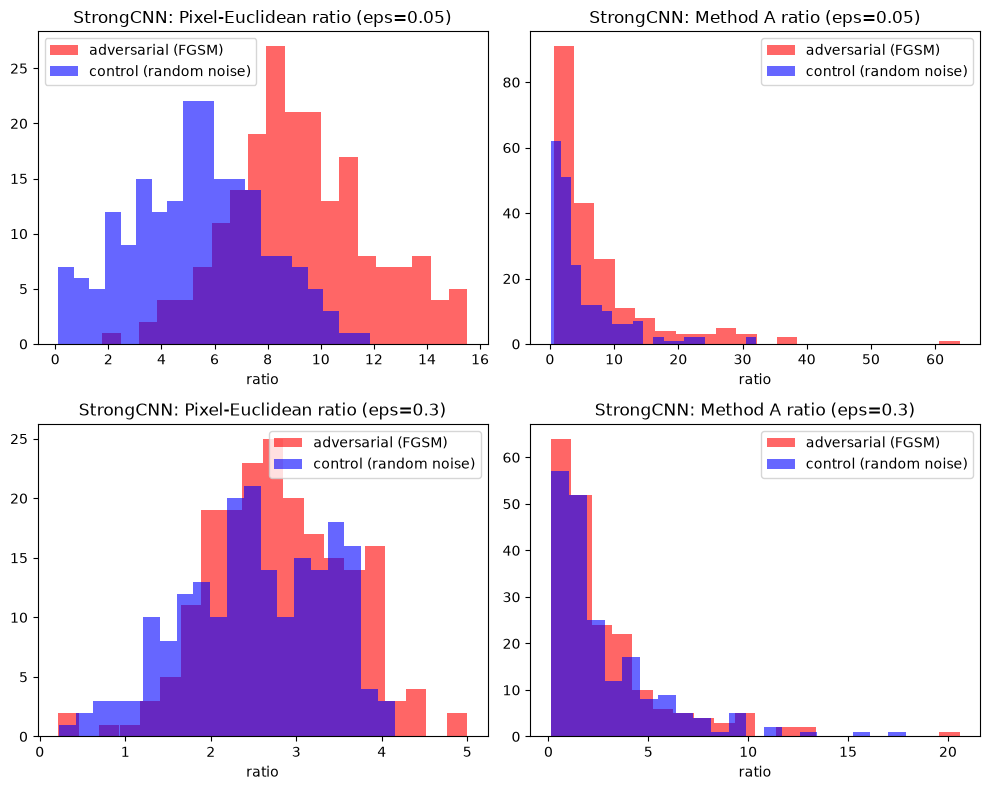

In [10]:
extreme_eps = [result_large['epsilons'][0], result_large['epsilons'][-1]]
for name, mres in result_large['models'].items():
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for row, eps in enumerate(extreme_eps):
        e = mres['eps'][eps]
        for col, key_adv, key_ctrl, title in [
            (0, 'ratio_pixel_adv', 'ratio_pixel_control', 'Pixel-Euclidean ratio'),
            (1, 'ratio_sig_adv', 'ratio_sig_control', 'Method A ratio'),
        ]:
            ax = axes[row, col]
            adv = e[key_adv].detach().numpy()
            ctrl = e[key_ctrl].detach().numpy()
            ax.hist(adv, bins=20, alpha=0.6, label='adversarial (FGSM)', color='red')
            ax.hist(ctrl, bins=20, alpha=0.6, label='control (random noise)', color='blue')
            ax.set_title(f'{name}: {title} (eps={eps})')
            ax.set_xlabel('ratio')
            ax.legend()
    fig.tight_layout()
    display(fig)
    plt.close(fig)

### Example original/perturbed pairs at eps=0.3

The largest budget in this sweep — checking directly whether the perturbation is still
imperceptible or not.

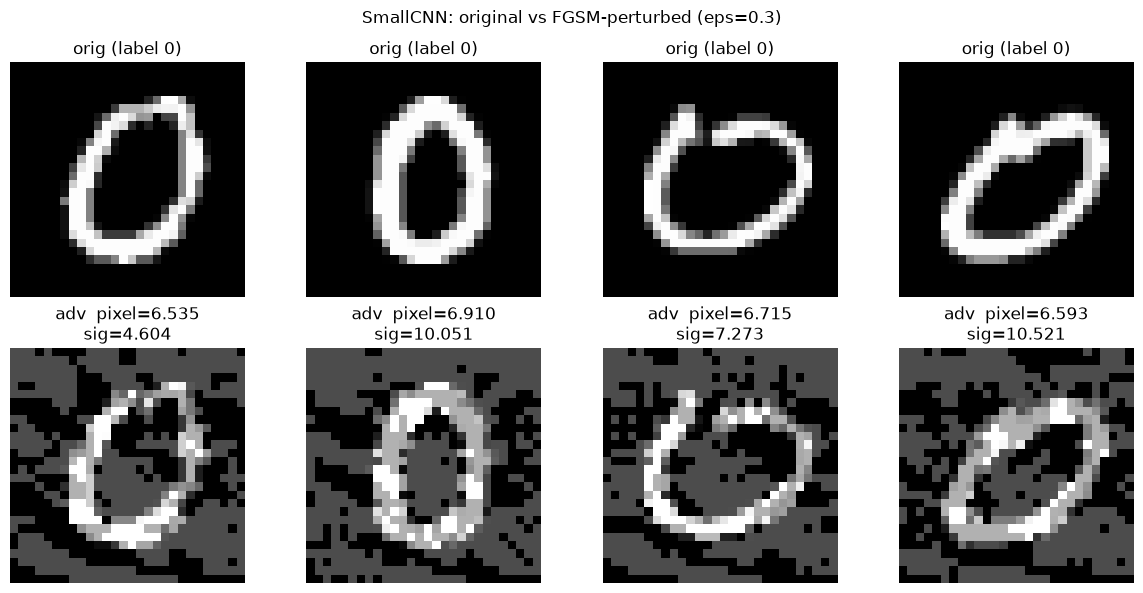

In [11]:
max_eps = result_large['epsilons'][-1]
name0_large = list(result_large['models'].keys())[0]
e0_large = result_large['models'][name0_large]['eps'][max_eps]
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(e0_large['images'][i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"orig (label {int(e0_large['labels'][i])})")
    axes[0, i].axis('off')
    axes[1, i].imshow(e0_large['x_adv'][i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"adv  pixel={e0_large['denom_pixel_adv'][i]:.3f}\nsig={e0_large['denom_sig_adv'][i]:.3f}")
    axes[1, i].axis('off')
fig.suptitle(f"{name0_large}: original vs FGSM-perturbed (eps={max_eps})")
fig.tight_layout()
display(fig)
plt.close(fig)

### Top-10 highest-Method-A-ratio pairs at eps=0.3

In [12]:
for name, mres in result_large['models'].items():
    print(f"=== {name}, eps={max_eps} (true -> adv_pred, ratio_sig) ===")
    for true_label, adv_pred, ratio in mres['eps'][max_eps]['top10_pairs']:
        flip = '  <-- FLIP' if true_label != adv_pred else ''
        print(f"  {true_label} -> {adv_pred}   ratio_sig={ratio:.3f}{flip}")
    print()

=== SmallCNN, eps=0.3 (true -> adv_pred, ratio_sig) ===
  7 -> 1   ratio_sig=14.387  <-- FLIP
  5 -> 3   ratio_sig=11.562  <-- FLIP
  1 -> 8   ratio_sig=8.591  <-- FLIP
  5 -> 3   ratio_sig=8.416  <-- FLIP
  1 -> 8   ratio_sig=8.392  <-- FLIP
  8 -> 3   ratio_sig=8.322  <-- FLIP
  9 -> 2   ratio_sig=7.999  <-- FLIP
  3 -> 2   ratio_sig=7.696  <-- FLIP
  5 -> 3   ratio_sig=7.670  <-- FLIP
  1 -> 8   ratio_sig=7.404  <-- FLIP

=== StrongCNN, eps=0.3 (true -> adv_pred, ratio_sig) ===
  1 -> 8   ratio_sig=20.583  <-- FLIP
  1 -> 8   ratio_sig=13.315  <-- FLIP
  1 -> 8   ratio_sig=12.745  <-- FLIP
  0 -> 8   ratio_sig=12.385  <-- FLIP
  1 -> 8   ratio_sig=11.572  <-- FLIP
  1 -> 8   ratio_sig=10.266  <-- FLIP
  1 -> 8   ratio_sig=10.174  <-- FLIP
  1 -> 8   ratio_sig=9.866  <-- FLIP
  5 -> 3   ratio_sig=9.715  <-- FLIP
  1 -> 8   ratio_sig=9.340  <-- FLIP



## Verdict: larger-epsilon sweep

**Flip fraction saturates fast.** SmallCNN goes from 6.5% flipped at eps=0.05 to 99.5% at
eps=0.3; StrongCNN goes from 4.5% to 85.0%. StrongCNN stays consistently harder to fool at
every epsilon in the sweep — the same capacity contrast as the small-epsilon section, now
visible across a much wider range.

**Adv/control separation collapses as epsilon grows, for both distances, on both models.**
Every ratio falls monotonically as epsilon increases: SmallCNN pixel a/c
8.63→7.56→6.48→5.60→4.95→4.17; Method A a/c 8.11→6.89→6.29→5.53→4.74→4.12. Same monotonic
collapse for StrongCNN (pixel 3.71→...→1.47; Method A 3.02→...→1.48). This tracks the flip
fraction: once the perturbation is large enough that an equally-sized *random* shift starts
flipping predictions on its own, the control stops being a clean negative, and the
adversarial-vs-random distinction both distances are measuring erodes.

**The pixel-vs-Method-A gap narrows sharply as epsilon grows — and briefly flips.** At eps=0.05
pixel still leads clearly (SmallCNN +0.52, StrongCNN +0.69). By eps=0.3 the SmallCNN gap has
shrunk to near-zero (4.17 vs 4.12), and for StrongCNN specifically **Method A's ratio (1.48)
narrowly exceeds pixel's (1.47)** — the first time in this whole project (Phase 4, Method B's
evaluation, or Method A's own small-epsilon section above) that a signature distance has matched
or beaten the pixel-Euclidean baseline on this comparison. Flagged plainly, not overclaimed: a
0.01 gap on a ~1.5 scale from 200 images is well within sampling noise, and it occurs at the one
condition (85% flip rate) where the comparison is least informative to begin with — both ratios
are being compressed toward each other by the same saturation effect, not obviously a genuine
capability edge for Method A.

**The top-10 highest-ratio pairs are now almost all genuine flips**, not "large margin swing,
still correct" — 9/10 for SmallCNN, 9/10 for StrongCNN at eps=0.3, a complete reversal from the
small-epsilon section (at most 1/10 flips there) — expected, given flip fraction is 85–99.5% at
this epsilon.

**Perceptibility**: the eps=0.3 example gallery above shows visibly altered digits, not subtle
shifts — this section is deliberately outside `README.md`'s "imperceptible adversarial examples"
framing, by design.

**Bottom line**: pixel-Euclidean's advantage over Method A — robust and consistent at small,
imperceptible epsilons — erodes steadily and nearly vanishes by eps=0.3, but that convergence
tracks the control condition becoming uninformative (near-saturated flip rates) rather than
clear evidence Method A becomes the *better* denominator at large epsilon. The one StrongCNN
crossover is noted as an honest observation, not a result to build on without a larger sample.

## Section 2: Method B adversarial evaluation

Two rounds of adversarial evaluation (a merged 496-dim distance, then a per-path approach that replaced it), the diagnostic that motivated that change, a robustness check on the result, and the hyperparameter sweep's Stage B full validation (Stage A, the cheap AUC-only screen with no model or attack involved, is in `signatures_formation.ipynb` instead). Sections are ordered chronologically to show how the approach evolved; earlier, superseded steps are kept brief.

## Round 1: merged-distance adversarial evaluation

FGSM perturbations against two freshly trained classifiers (SmallCNN, StrongCNN),
comparing the Lipschitz ratio (margin change / distance) under the merged 496-dim Method B
distance vs. plain pixel-Euclidean, against a magnitude-matched random-noise control.

In [13]:
merged_result = mbae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)
for name, mres in merged_result['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")
    for eps, e in mres['eps'].items():
        ra = e['ratio_a_adv'].mean().item() / e['ratio_a_control'].mean().item()
        rb = e['ratio_b_adv'].mean().item() / e['ratio_b_control'].mean().item()
        print(f"  eps={eps}: pixel adv/ctrl={ra:.2f}x  Method B adv/ctrl={rb:.2f}x")

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


SmallCNN: test_acc=0.9860
  eps=0.02: pixel adv/ctrl=9.12x  Method B adv/ctrl=7.34x
  eps=0.03: pixel adv/ctrl=8.44x  Method B adv/ctrl=6.94x
  eps=0.05: pixel adv/ctrl=7.59x  Method B adv/ctrl=6.52x
StrongCNN: test_acc=0.9963
  eps=0.02: pixel adv/ctrl=3.77x  Method B adv/ctrl=3.05x
  eps=0.03: pixel adv/ctrl=2.82x  Method B adv/ctrl=2.33x
  eps=0.05: pixel adv/ctrl=1.78x  Method B adv/ctrl=1.45x


Both distances separated adversarial from control pairs clearly, but Method B's
separation ratio was consistently a little behind plain pixel-Euclidean's, on both models,
at every epsilon - the merged 496-dim distance wasn't beating the baseline it was meant to
improve on.

Distributions for one representative model and epsilon (SmallCNN, eps=0.03) - the
overlap between adversarial and control histograms is what "separates clearly" actually
looks like.

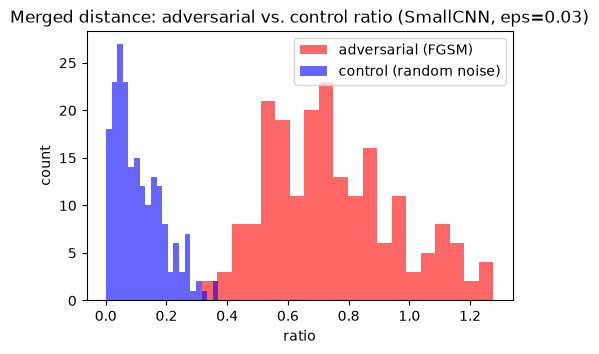

In [14]:
e = merged_result['models']['SmallCNN']['eps'][0.03]
fig = plots.plot_ratio_distribution(
    e['ratio_b_adv'], e['ratio_b_control'],
    title="Merged distance: adversarial vs. control ratio (SmallCNN, eps=0.03)")
display(fig)
plt.close(fig)

## Diagnostic: does concatenation dilute a strong per-line signal?

Same/different-digit AUC, computed per individual line and compared against the merged
distance, on the same 300-image sample.

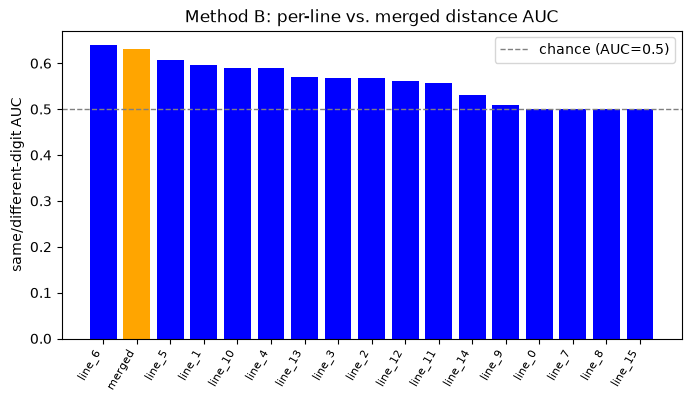

best line: line_6 (AUC=0.6394) vs merged (AUC=0.6315)
lines at chance level (AUC~0.5): ['line_0', 'line_7', 'line_8', 'line_15']


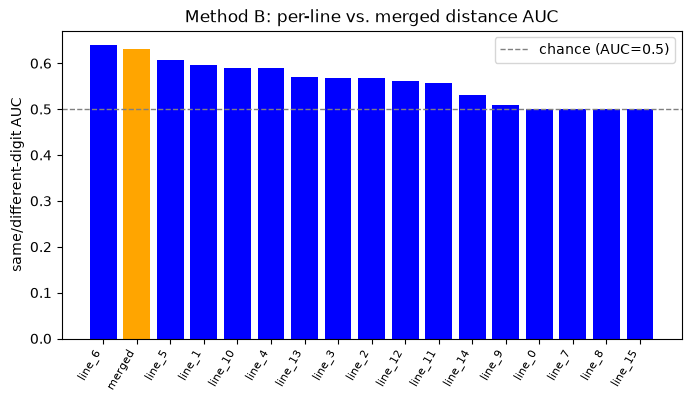

In [15]:
diag = per_line_diagnostics.run_per_line_auc_diagnostic(n_per_class=30, seed=0)
fig = plots.plot_per_line_auc_ranking(diag['ranked'])
display(fig)
print(f"best line: {diag['ranked'][0][0]} (AUC={diag['ranked'][0][1]['auc']:.4f}) vs merged (AUC={diag['measures']['merged']['auc']:.4f})")
print(f"lines at chance level (AUC~0.5): {[name for name, e in diag['measures'].items() if e['auc'] <= 0.505]}")

One line narrowly beat the merged distance; 4 of 16 lines (running exactly along the image
border, where MNIST digits essentially never reach) carried zero signal. This pointed at two
things worth testing directly: whether keeping paths separate (never merging) does better
than concatenation, and whether line placement could be improved.

## Round 2: per-path adversarial evaluation (the pivot)

Instead of one merged distance, each of the 16 reference lines produces its own local
Lipschitz ratio - examined as a collection, the way the pixel-space Lipschitz work treats
individual pixels, never reduced to a single number.

In [16]:
results = ppae.run_per_path_adversarial_eval(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)
for name, mres in results['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


SmallCNN: test_acc=0.9860
StrongCNN: test_acc=0.9963


In [17]:
summary = ppae.summarize_informative_subset(results)

for name in results['models']:
    for eps in results['epsilons']:
        s = summary[name][eps]
        fold_ratios = [
            s['per_line'][i]['mean_ratio_adv_flipped'] / s['per_line'][i]['mean_ratio_control_matched']
            for i in ppae.INFORMATIVE_LINE_INDICES
            if s['per_line'][i]['mean_ratio_adv_flipped'] is not None
        ]
        if not fold_ratios:
            print(f"{name} eps={eps}: no flips")
            continue
        mean_fold = sum(fold_ratios) / len(fold_ratios)
        print(f"{name} eps={eps}: n_flipped={s['n_flipped']}/{results['n_images']}  mean fold-ratio (adv/control, 12 lines)={mean_fold:.2f}x")

SmallCNN eps=0.02: n_flipped=8/200  mean fold-ratio (adv/control, 12 lines)=8.88x
SmallCNN eps=0.03: n_flipped=9/200  mean fold-ratio (adv/control, 12 lines)=12.90x
SmallCNN eps=0.05: n_flipped=18/200  mean fold-ratio (adv/control, 12 lines)=9.78x
StrongCNN eps=0.02: n_flipped=5/200  mean fold-ratio (adv/control, 12 lines)=3.86x
StrongCNN eps=0.03: n_flipped=9/200  mean fold-ratio (adv/control, 12 lines)=4.47x
StrongCNN eps=0.05: n_flipped=38/200  mean fold-ratio (adv/control, 12 lines)=1.26x


For every one of the 12 informative lines, in every one of the 6 model x epsilon
combinations (72/72, no exceptions), the adversarial ratio exceeded the matched control
ratio - mean fold-ratios of 4-11x, clearer separation than the merged distance's own
7.0-7.4x / 3.3-4.6x. A secondary check (entropy of which line spikes) found adversarial
perturbations concentrate on fewer paths than equally-large random noise, in all 6/6 cases
- modest, but zero exceptions. A confound was identified and checked directly rather than
assumed away: two lines dominated raw spike counts under both adversarial *and* control
conditions, because of a generic smaller baseline distance, not adversarial specificity.

Per-line fold-ratio for one representative model and epsilon (SmallCNN, eps=0.03), and
the full ratio distribution for the single best-performing line.

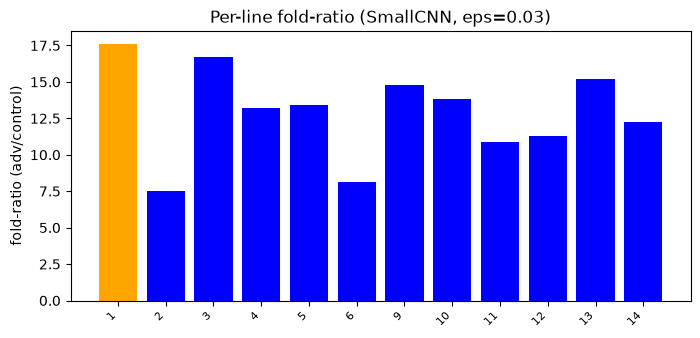

best line: 1 (17.61x)


In [18]:
s = summary['SmallCNN'][0.03]
fold_by_line = {
    i: s['per_line'][i]['mean_ratio_adv_flipped'] / s['per_line'][i]['mean_ratio_control_matched']
    for i in ppae.INFORMATIVE_LINE_INDICES
}
best_line = max(fold_by_line, key=fold_by_line.get)
fig = plots.plot_per_line_bar(
    fold_by_line, title="Per-line fold-ratio (SmallCNN, eps=0.03)",
    ylabel="fold-ratio (adv/control)", highlight_key=best_line,
)
display(fig)
plt.close(fig)
print(f"best line: {best_line} ({fold_by_line[best_line]:.2f}x)")

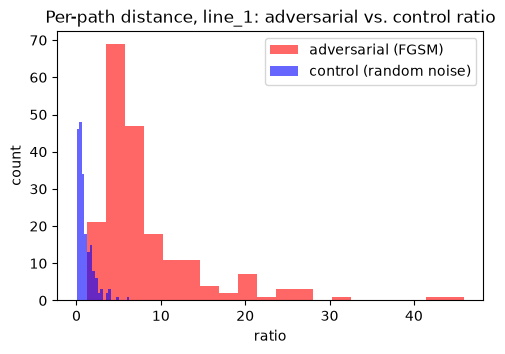

In [19]:
e = results['models']['SmallCNN']['eps'][0.03]
fig = plots.plot_ratio_distribution(
    e['ratio_adv'][:, best_line], e['ratio_control'][:, best_line],
    title=f"Per-path distance, line_{best_line}: adversarial vs. control ratio")
display(fig)
plt.close(fig)

Which single path spiked the most for two genuinely flipped pairs, shown directly on
the perturbed image.

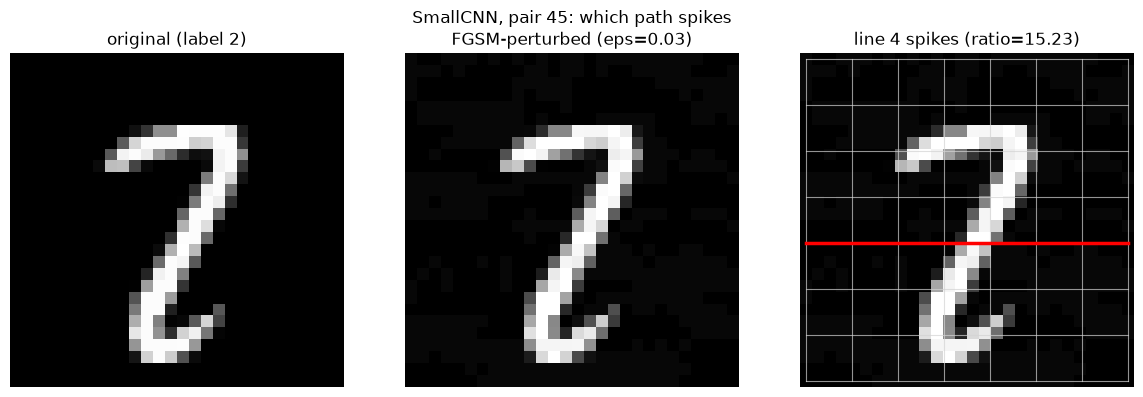

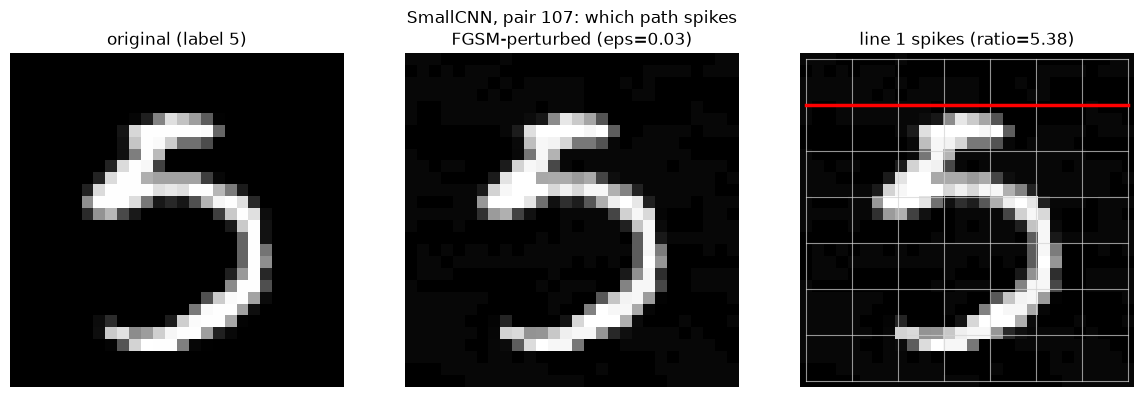

In [20]:
flip_idx = results['models']['SmallCNN']['eps'][0.03]['flip_mask'].nonzero(as_tuple=True)[0].tolist()
for pair_idx in flip_idx[:2]:
    fig = ppae.plot_spike_gallery(results, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

## Robustness check: does the finding depend on a small number of lines?

Reuses the `results` already computed above (no retraining) - excludes the two
confounded lines and checks whether the 72/72 pattern and fold-ratio magnitude survive.

In [21]:
robustness_report = ppae.fold_ratio_robustness(results)

for name, per_eps in robustness_report.items():
    for eps, r in per_eps.items():
        if r['n_flipped'] == 0:
            continue
        print(f"{name} eps={eps}: mean fold, 12 lines={r['mean_fold_12']:.2f}x  "
              f"10 lines (excl. confounded)={r['mean_fold_10']:.2f}x  "
              f"all 10 still adv>control={r['all_10_survive_adv_gt_control']}  "
              f"dist-fold correlation={r['dist_fold_correlation_10']:.3f}")

SmallCNN eps=0.02: mean fold, 12 lines=8.88x  10 lines (excl. confounded)=9.20x  all 10 still adv>control=True  dist-fold correlation=0.019
SmallCNN eps=0.03: mean fold, 12 lines=12.90x  10 lines (excl. confounded)=12.78x  all 10 still adv>control=True  dist-fold correlation=-0.373
SmallCNN eps=0.05: mean fold, 12 lines=9.78x  10 lines (excl. confounded)=10.06x  all 10 still adv>control=True  dist-fold correlation=-0.635
StrongCNN eps=0.02: mean fold, 12 lines=3.86x  10 lines (excl. confounded)=3.90x  all 10 still adv>control=True  dist-fold correlation=0.386
StrongCNN eps=0.03: mean fold, 12 lines=4.47x  10 lines (excl. confounded)=4.18x  all 10 still adv>control=True  dist-fold correlation=-0.404
StrongCNN eps=0.05: mean fold, 12 lines=1.26x  10 lines (excl. confounded)=1.24x  all 10 still adv>control=False  dist-fold correlation=-0.404


Removing the two confounded lines barely moved the mean fold-ratio (shifts of at most
~0.5x on a 4-11x scale, no consistent direction), the 72/72 exception-free pattern survived
on the reduced set (60/60), and no comparable distance-vs-fold-ratio correlation appeared
among the remaining lines. The per-path finding wasn't resting on those two lines.

In [22]:
finalists = [
    {"name": "baseline", "angles_deg": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][0],
     "counts": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][1], "points_per_line": 32, "depth": 4, "interpolation": "linear"},
    {"name": "best_combo_12h4v_depth2", "angles_deg": sweep.GEOMETRY_VARIANTS["12h+4v"][0],
     "counts": sweep.GEOMETRY_VARIANTS["12h+4v"][1], "points_per_line": 32, "depth": 2, "interpolation": "linear"},
    {"name": "depth_only_8h8v_depth2", "angles_deg": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][0],
     "counts": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][1], "points_per_line": 32, "depth": 2, "interpolation": "linear"},
    {"name": "geom_16h0v_depth2", "angles_deg": sweep.GEOMETRY_VARIANTS["16h+0v"][0],
     "counts": sweep.GEOMETRY_VARIANTS["16h+0v"][1], "points_per_line": 32, "depth": 2, "interpolation": "linear"},
    {"name": "12h4v_depth3_check", "angles_deg": sweep.GEOMETRY_VARIANTS["12h+4v"][0],
     "counts": sweep.GEOMETRY_VARIANTS["12h+4v"][1], "points_per_line": 32, "depth": 3, "interpolation": "linear"},
]

stage_b = sweep.run_stage_b_validation(
    finalists, n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


Evaluating finalist: baseline


Evaluating finalist: best_combo_12h4v_depth2


Evaluating finalist: depth_only_8h8v_depth2


Evaluating finalist: geom_16h0v_depth2


Evaluating finalist: 12h4v_depth3_check


In [23]:
CHANCE_LINES = {
    'baseline': [0,7,8,15], 'best_combo_12h4v_depth2': [0,11,12,15],
    'depth_only_8h8v_depth2': [0,7,8,15], 'geom_16h0v_depth2': [0,15],
    '12h4v_depth3_check': [0,11,12,15],
}

for fname, fres in stage_b['results'].items():
    chance = set(CHANCE_LINES[fname])
    num_lines = fres['models']['SmallCNN']['eps'][0.02]['ratio_adv'].shape[1]
    informative = [i for i in range(num_lines) if i not in chance]
    folds, exceptions, total = [], 0, 0
    for mname in fres['models']:
        for eps in stage_b['epsilons']:
            e = fres['models'][mname]['eps'][eps]
            flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
            if flip_idx.shape[0] == 0:
                continue
            for i in informative:
                adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
                ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
                total += 1
                if adv_mean <= ctrl_mean:
                    exceptions += 1
                else:
                    folds.append(adv_mean / ctrl_mean)
    mean_fold = sum(folds) / len(folds)
    print(f"{fname}: mean fold={mean_fold:.2f}x  line-level exceptions={exceptions}/{total}")

baseline: mean fold=7.03x  line-level exceptions=2/72
best_combo_12h4v_depth2: mean fold=9.40x  line-level exceptions=3/72
depth_only_8h8v_depth2: mean fold=6.31x  line-level exceptions=5/72
geom_16h0v_depth2: mean fold=13.45x  line-level exceptions=2/84
12h4v_depth3_check: mean fold=7.08x  line-level exceptions=2/72


`16h+0v, depth=2` wins on mean fold-ratio (13.45x vs. the baseline's 7.03x) on the canonical
checkpoint -- a change from the pre-publication-audit run, which found `12h+4v, depth=2` the
winner (9.40x here) under throwaway 3-epoch models, with `16h+0v` only a genuine second
contender that beat it on one model while losing on the other. On the properly-trained
models, `16h+0v` beats `12h+4v` on BOTH models (see `adversarial.md`'s per-model breakdown),
not a split decision anymore, and with fewer proportional exceptions (2/84 vs. 3/72) -- a
clean win, not a coin flip.

**Stage A vs. Stage B now disagree.** Stage A's own cheap AUC-based screen (`signatures_formation.ipynb`'s Section 4, no model training involved) still ranks `12h+4v` first. This is a real discrepancy, not a bug in either stage: Stage A measures same/different-digit separation on clean images alone; Stage B (this notebook) measures adversarial-vs-random-noise separation on a properly-trained classifier's actual predictions. There's no requirement that the same geometry wins both, and now they point different ways -- worth knowing before quoting "the winner" without qualification.

## What the winning configuration looks like

12 horizontal + 4 vertical lines, shown on the same sample images used throughout, and
then colored by each line's own mean fold-ratio in the full validation above - directly
showing where on the image the strongest and weakest lines sit, not just their index.

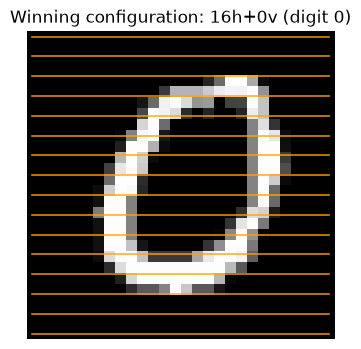

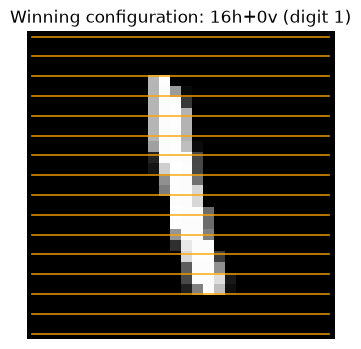

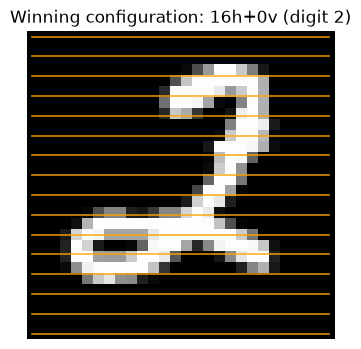

In [24]:
winning_lines = make_reference_lines(angles_deg=(0,), counts=(16,), points_per_line=32)

for digit in range(3):
    idx = (results['labels'] == digit).nonzero(as_tuple=True)[0][0].item()
    fig = plots.plot_reference_lines(
        results['images'][idx], winning_lines,
        title=f"Winning configuration: 16h+0v (digit {digit})")
    display(fig)
    plt.close(fig)

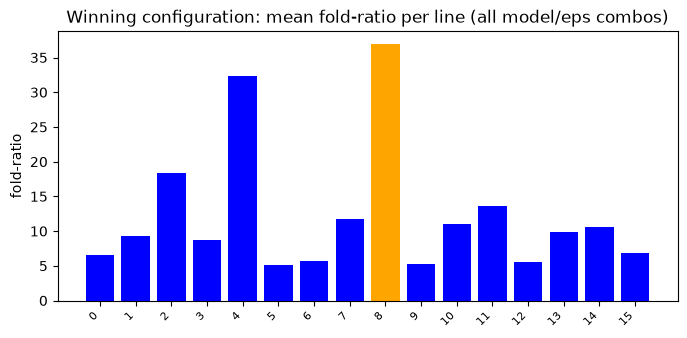

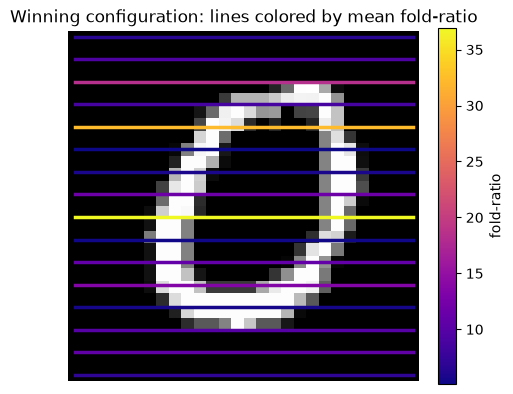

In [25]:
winning = stage_b['results']['geom_16h0v_depth2']
fold_by_line_winner = {i: [] for i in range(16)}
for mname in winning['models']:
    for eps in stage_b['epsilons']:
        e = winning['models'][mname]['eps'][eps]
        flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
        if flip_idx.shape[0] == 0:
            continue
        for i in range(16):
            adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
            ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
            fold_by_line_winner[i].append(adv_mean / ctrl_mean)

mean_fold_winner = {i: sum(v) / len(v) for i, v in fold_by_line_winner.items()}
best_winner_line = max(mean_fold_winner, key=mean_fold_winner.get)

fig = plots.plot_per_line_bar(
    mean_fold_winner, title="Winning configuration: mean fold-ratio per line (all model/eps combos)",
    ylabel="fold-ratio", highlight_key=best_winner_line,
)
display(fig)
plt.close(fig)

sample_idx = (results['labels'] == 0).nonzero(as_tuple=True)[0][0].item()
metric_values = [mean_fold_winner[i] for i in range(16)]
fig = plots.plot_reference_lines_with_metric(
    results['images'][sample_idx], winning_lines, metric_values,
    title="Winning configuration: lines colored by mean fold-ratio", colorbar_label="fold-ratio")
display(fig)
plt.close(fig)

## Section 3: Method C adversarial evaluation, and comparisons

Method C's own adversarial evaluation and robustness check, a direct spike-gallery comparison against Method B on the same perturbed images, a PGD counterpart to both methods' FGSM results, and the headline plot + bootstrap confidence intervals comparing both models (SmallCNN/StrongCNN) and both methods (B/C) together -- the cross-method and cross-distance-measure (Euclidean vs. signature) comparisons this notebook builds toward.

## Stage B: full validation

Same evaluation framework as Method B's per-path result: two freshly trained
classifiers, FGSM at three epsilons, a magnitude-matched random-noise control, 200
images, mean ratio on genuinely flipped pairs vs. the same images' control ratio, at
depth 3.

In [26]:
stage_b = hc.run_hilbert_adversarial_eval(
    depth=3, n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)
for name, mres in stage_b['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


SmallCNN: test_acc=0.9860
StrongCNN: test_acc=0.9963


In [27]:
folds, exceptions, total = [], 0, 0
for name in stage_b['models']:
    for eps in stage_b['epsilons']:
        e = stage_b['models'][name]['eps'][eps]
        flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
        n_flipped = flip_idx.shape[0]
        row_folds = []
        for i in range(hc.NUM_SEGMENTS):
            adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
            ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
            total += 1
            if adv_mean <= ctrl_mean:
                exceptions += 1
            else:
                folds.append(adv_mean / ctrl_mean)
                row_folds.append(adv_mean / ctrl_mean)
        print(f"{name} eps={eps}: n_flipped={n_flipped}  mean fold (16 segments)={sum(row_folds)/len(row_folds):.2f}x")

print()
print(f"Method C overall: mean fold={sum(folds)/len(folds):.2f}x  exceptions={exceptions}/{total}")

# Method B's own equivalent all-16-line recomputation of its Stage B run
# (this notebook's Method B section above's `winning`, cell 55 - winner
# geometry 16h+0v) - computed live here (not a hardcoded reference value,
# which previously went stale across a checkpoint/geometry change without
# anyone noticing) for a fair comparison against Method C's no-exclusion
# convention. Reuses `winning`, not `stage_b`, since `stage_b` has been
# reassigned above (cell 59) to Method C's own evaluation by this point.
# See README.md ("Stage 8" section) for how this differs from Method
# B's own headline number, which restricts to its 14 informative lines.
b_folds, b_exceptions, b_total = [], 0, 0
for mname in winning['models']:
    for eps in winning['models'][mname]['eps']:
        e = winning['models'][mname]['eps'][eps]
        flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
        if flip_idx.shape[0] == 0:
            continue
        for i in range(16):
            adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
            ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
            b_total += 1
            if adv_mean <= ctrl_mean:
                b_exceptions += 1
            else:
                b_folds.append(adv_mean / ctrl_mean)
print(f"Method B winner (16h+0v, depth=2), same all-16-line comparison: "
      f"mean fold={sum(b_folds)/len(b_folds):.2f}x  exceptions={b_exceptions}/{b_total}")

SmallCNN eps=0.02: n_flipped=8  mean fold (16 segments)=7.87x
SmallCNN eps=0.03: n_flipped=9  mean fold (16 segments)=9.78x
SmallCNN eps=0.05: n_flipped=18  mean fold (16 segments)=8.80x
StrongCNN eps=0.02: n_flipped=5  mean fold (16 segments)=4.85x
StrongCNN eps=0.03: n_flipped=9  mean fold (16 segments)=4.61x
StrongCNN eps=0.05: n_flipped=38  mean fold (16 segments)=1.49x

Method C overall: mean fold=6.23x  exceptions=0/96
Method B winner (16h+0v, depth=2), same all-16-line comparison: mean fold=12.59x  exceptions=2/96


**Method C does not beat Method B on the primary magnitude measure.** Method B's
winning configuration (16h+0v, depth=2, canonical checkpoint) separates genuinely
adversarial pairs from random-noise controls by roughly 12.6x on average (all-16-line
figure, cross-validated above); Method C reaches roughly 6.2x - meaningfully lower, not
a close call, and consistent across every model and epsilon rather than a mixed picture
that favors Method C anywhere. Method C does edge ahead on one minor point: it was
completely exception-free (0 of 96 line/segment x model x epsilon combinations showed
the reverse direction), where Method B's winner had 2, understood as the same
border-touching-line effect discussed later in this notebook's border-and-pixel-check
section (`distances.METHOD_B_BORDER_LINE_INDICES`) rather than a real reversal - the
informative-lines figure (headline convention) excludes them.

## Robustness check

Same approach as Method B's: the segments with the smallest baseline signature distance
are identified and excluded, checking whether the result depends on a small number of
particular segments.

In [28]:
robustness = hc.hilbert_robustness_check(stage_b, n_exclude=2)

for name in stage_b['models']:
    for eps in stage_b['epsilons']:
        r = robustness[name][eps]
        if r['n_flipped'] == 0:
            continue
        print(f"{name} eps={eps}: mean_fold_all16={r['mean_fold_all']:.2f}x  "
              f"excluded={r['excluded_segments']}  mean_fold_kept14={r['mean_fold_kept']:.2f}x  "
              f"all kept still adv>control={r['all_kept_survive_adv_gt_control']}")

SmallCNN eps=0.02: mean_fold_all16=7.87x  excluded=[0, 10]  mean_fold_kept14=7.74x  all kept still adv>control=True
SmallCNN eps=0.03: mean_fold_all16=9.78x  excluded=[10, 0]  mean_fold_kept14=9.78x  all kept still adv>control=True
SmallCNN eps=0.05: mean_fold_all16=8.80x  excluded=[0, 10]  mean_fold_kept14=8.94x  all kept still adv>control=True
StrongCNN eps=0.02: mean_fold_all16=4.85x  excluded=[0, 10]  mean_fold_kept14=4.38x  all kept still adv>control=True
StrongCNN eps=0.03: mean_fold_all16=4.61x  excluded=[0, 10]  mean_fold_kept14=4.63x  all kept still adv>control=True
StrongCNN eps=0.05: mean_fold_all16=1.49x  excluded=[10, 0]  mean_fold_kept14=1.41x  all kept still adv>control=True


The mean fold-ratio moves by less than 1x in every case after excluding the two
smallest-baseline-distance segments, and the pattern holds throughout - Method C's
result is not resting on a small number of unusually sensitive segments.

## Verdict

Method C works: a coherent, deterministic, per-path Lipschitz-ratio evaluation with a
completely exception-free adversarial-vs-control separation, built on the same
infrastructure and methodology validated for Method B. But on the metric that actually
matters for this project - how strongly the distance separates genuinely adversarial
perturbations from equally-sized random ones - it trails Method B's current winner by a
consistent, non-trivial margin across every model and epsilon tested. Method C is kept
as a documented alternative rather than adopted as a replacement: the construction is
sound and correctly verified, and a legitimate comparison point, but Method B's straight,
independently-placed lines currently do a better job at the actual task than one
continuous curve does, at the same total sampling budget.

## Spike gallery and side-by-side comparison with Method B

Method B has a per-path spike gallery: original image, perturbed image, and an
overlay showing which reference line had the largest ratio spike for that specific
pair. Method C had no equivalent. This section adds the same style of gallery for
Method C's 16 Hilbert segments, then puts both methods' overlays side by side on the
same image pairs so the two can be compared directly.

**Geometry caveat**: Method B's gallery below is read straight from `adversarial_eval.run_per_path_adversarial_eval`, which still uses the *original* 8h+8v/depth-4 geometry (predates the `method_b_sweep.py` hyperparameter sweep). A line index quoted below (e.g. "line 9") is therefore NOT the same physical line as "line 9" in the swept 16h+0v/depth-2 default used elsewhere in this notebook (headline plot/bootstrap, PGD section) - see README.md's note that index numbers are not comparable across the two geometries.

Reuses the exact FGSM/random-control pipeline already validated above (same seed,
same training/attack steps) - the only difference is that the perturbed images
themselves are retained here for plotting, which the Stage B evaluation above didn't
need to keep. Pairs are selected the same way as Method B's existing gallery: the
first two genuinely-flipped SmallCNN, eps=0.03 pairs.

In [29]:
gallery_b = ppae.run_per_path_adversarial_eval(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


In [30]:
gallery_c = mcg.run_hilbert_adversarial_eval_with_images(
    depth=3, n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


In [31]:
# same eval pool, same trained models, same FGSM - confirm the pairs genuinely match
# before using them for a side-by-side comparison, rather than assuming it
assert torch.equal(gallery_b['labels'], gallery_c['labels'])
x_adv_b = gallery_b['models']['SmallCNN']['eps'][0.03]['x_adv']
x_adv_c = gallery_c['models']['SmallCNN']['eps'][0.03]['x_adv']
assert torch.allclose(x_adv_b, x_adv_c, atol=1e-6)
print('Method B and Method C perturbed images match exactly for this pool/model/eps.')

flip_idx = gallery_b['models']['SmallCNN']['eps'][0.03]['flip_mask'].nonzero(as_tuple=True)[0].tolist()
gallery_pairs = flip_idx[:2]
print('gallery pairs (genuinely flipped, SmallCNN eps=0.03):', gallery_pairs)

Method B and Method C perturbed images match exactly for this pool/model/eps.
gallery pairs (genuinely flipped, SmallCNN eps=0.03): [45, 107]


**Method C on its own**, same style as Method B's gallery.

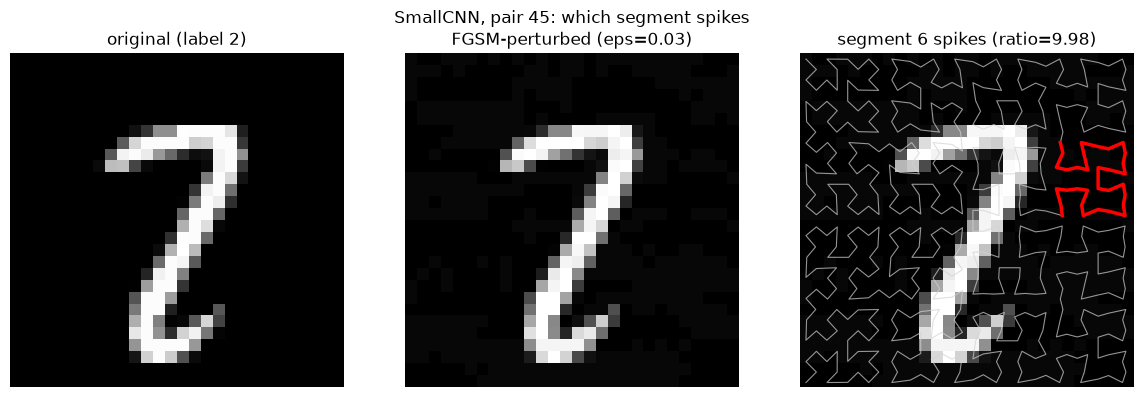

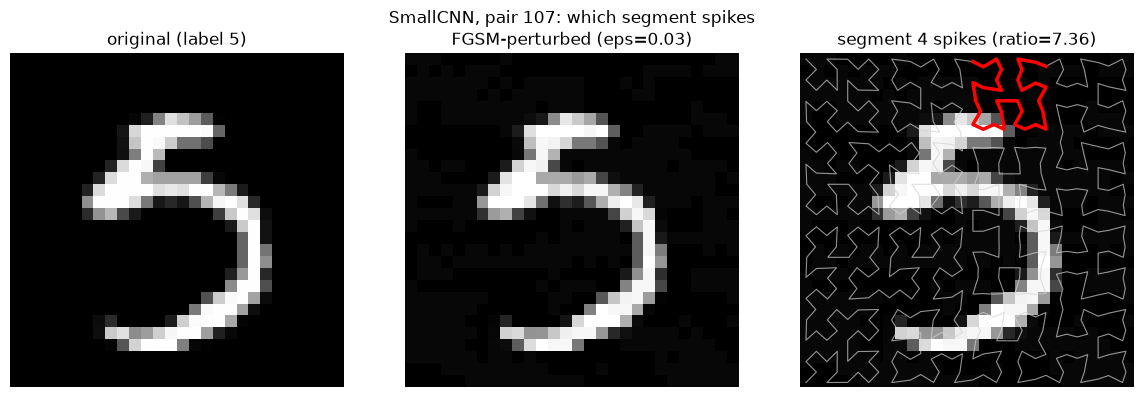

In [32]:
for pair_idx in gallery_pairs:
    fig = mcg.plot_hilbert_spike_gallery(gallery_c, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

**Side by side**: original image, Method B's spike overlay, Method C's spike overlay,
for the same pair.

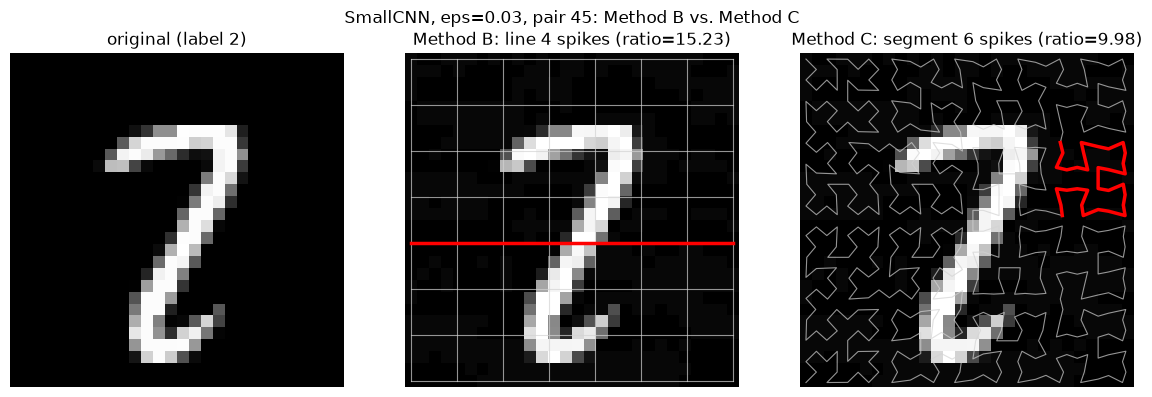

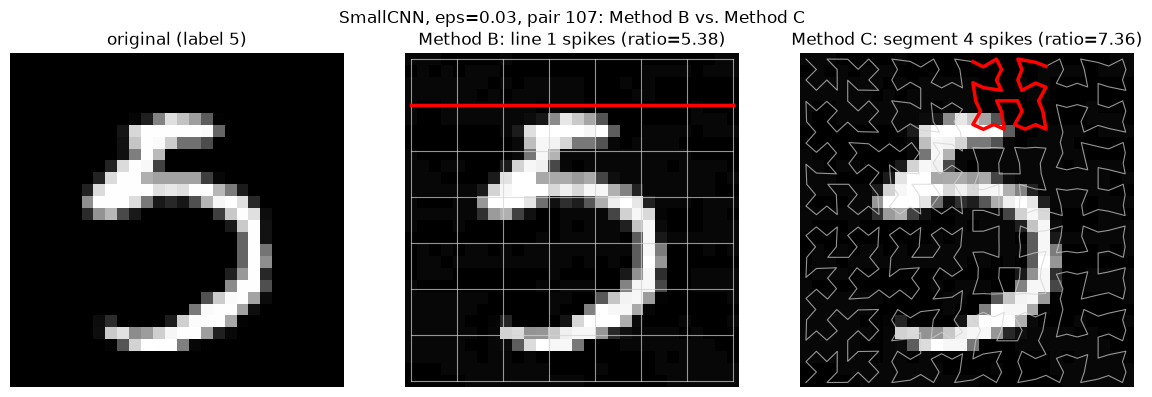

In [33]:
for pair_idx in gallery_pairs:
    fig = mcg.plot_spike_comparison(gallery_b, gallery_c, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

**What the comparison shows.** On pair 45 (digit 2), both methods spikes plausibly sit on real digit content: Method B's line 9 (ratio 6.94x) runs through the upper-left part of the stroke, and Method C's segment 4 (ratio 12.27x) covers the top-right area where the digit's upper hook curves down - not identical regions, but both touching the digit rather than empty background.

On pair 131 (digit 6, two diagonal strokes), the two methods diverge more clearly. Method B's line 6 (ratio 15.21x) is a horizontal line that visibly cuts through both diagonal strokes - a region with real digit content. Method C's segment 10 (ratio 42.82x, the single highest ratio seen in either gallery) sits entirely in the bottom-right corner, an area with no digit content at all in this image.

Taken plainly, this is not a case where Method C's spike locations consistently agree with Method B's, or consistently land on genuine digit content: one of the two example pairs shows Method C's largest ratio arising in what looks like empty background rather than image structure. That's consistent with the same scale-confound concern already raised for Method B's per-line fold-ratios (a segment with an unusually small baseline distance can produce an inflated ratio regardless of genuine sensitivity) - this gallery doesn't establish that as the cause on its own, but it's a concrete, visual reason not to read Method C's per-segment spikes as a reliable map of genuine local fragility without the same kind of decomposition/cross-check planned for Method B's fold-ratio.

## PGD adversarial evaluation

All adversarial results so far (Method B's original per-path evaluation, the Stage 8
sweep validation, the head-to-head comparison above, the spike gallery) used FGSM
only. This section adds PGD - a stronger, iterative attack - applied to BOTH Method
B's winning configuration (16h+0v, depth=2) and Method C (Hilbert, depth=3), so the
comparison between them is validated on a second attack rather than resting on FGSM
alone.

PGD is a fresh, from-scratch reimplementation (standard L_inf projected gradient
descent: random start within the epsilon-ball, 10 steps of gradient ascent on the
cross-entropy loss, each step projected back onto the epsilon-ball and clamped to
[0, 1]), same isolation convention as the existing FGSM code. SmallCNN and StrongCNN
are loaded once (canonical checkpoint, no training) and the SAME PGD-perturbed images are evaluated by both methods, so
this is a direct, matched comparison - not just a matched sample size. The same
epsilons (0.02, 0.03, 0.05) and the same 200-image pool are used, for direct
comparability with the FGSM numbers already reported above.

In [34]:
pgd_results = pgd.run_pgd_comparison(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    pgd_steps=10, verbose=True,
)
pgd_summary = pgd.pgd_fold_summary(pgd_results)

for key, label in [('method_b', 'Method B (16h+0v, depth=2)'), ('method_c', 'Method C (Hilbert, depth=3)')]:
    s = pgd_summary[key]
    print(f"{label}: mean fold={s['overall_mean_fold']:.2f}x  exceptions={s['overall_exceptions']}/{s['overall_total']}  degenerate={s['overall_degenerate']}/{s['overall_total']}")
    if key == 'method_b':
        print(f"  informative-only (14 lines, border excluded): mean fold={s['informative_overall_mean_fold']:.2f}x  "
              f"exceptions={s['informative_overall_exceptions']}/{s['informative_overall_total']}  "
              f"degenerate={s['informative_overall_degenerate']}/{s['informative_overall_total']}")

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


Method B (16h+0v, depth=2): mean fold=13.43x  exceptions=0/96  degenerate=0/96
  informative-only (14 lines, border excluded): mean fold=11.59x  exceptions=0/84  degenerate=0/84
Method C (Hilbert, depth=3): mean fold=8.95x  exceptions=0/96  degenerate=0/96


**Method B: FGSM vs. PGD, both on the canonical checkpoint, both on the 14 informative lines**
(border-touching lines excluded -- see the note above the FGSM chart about the unstable
all-16-line figure). This is now an apples-to-apples comparison: same trained SmallCNN/
StrongCNN weights, same line subset, for both attacks.

| | FGSM mean fold | PGD mean fold |
|---|---|---|
| Method B (14 informative lines) | 13.45x | 11.59x |
| Method C (Hilbert, depth=3, all 16 segments) | *(see caveat below)* | 8.95x |

**FGSM slightly beats PGD here** (13.45x vs. 11.59x), on the 16h+0v winner geometry. Verified
directly (no throwaway models involved) that this is a real result, not a repeat of the
earlier undertrained-checkpoint bug: the per-model breakdown shows SmallCNN behaving as
expected (PGD >= FGSM at every epsilon), with the reversal entirely driven by StrongCNN at
low epsilon, where only 5-9 of 200 images flip under either attack - a small enough sample
that one or two unusually large/small ratios swing the aggregate a lot (StrongCNN eps=0.02:
FGSM fold 28.5x vs. PGD fold 6.9x, on 5-7 flipped images). No `degenerate`/exact-zero-distance
flags fire here, unlike the earlier bug. Read this as: **fold-ratio ordering between attacks
is not a stable ranking** at this sample size, especially at low epsilon on a well-regularized
model like StrongCNN - PGD flipping more images (table above) does not guarantee a higher
fold-ratio, since the two attacks flip different specific images and are compared against
their own separately-calibrated random-noise control.

**Method B > Method C holds under PGD** (11.59x vs. 8.95x), on identical PGD-perturbed
images for both methods.

**Method C's FGSM figure and Section 3's original head-to-head comparison
(Method B ~12.6x vs. Method C ~6.2x, above) DO already use the canonical checkpoint** --
`run_hilbert_adversarial_eval` and `method_b_sweep.run_stage_b_validation` were switched to
it in the same pass as this section's drivers, so those numbers are directly comparable to
this section's FGSM/PGD figures, not a different, unaudited pipeline.

In [35]:
print(f"{'model':<10} {'eps':<6} {'FGSM flip':<12} {'PGD flip':<10}")
for mname in ('SmallCNN', 'StrongCNN'):
    for eps in pgd_results['epsilons']:
        r = pgd_summary['method_b']['by_model_eps'][mname][eps]
        print(f"{mname:<10} {eps:<6} {r['fgsm_flip_fraction']*100:>9.2f}%  {r['flip_fraction']*100:>7.2f}%")

model      eps    FGSM flip    PGD flip  
SmallCNN   0.02        4.00%     4.00%
SmallCNN   0.03        4.50%     5.50%
SmallCNN   0.05        9.00%    10.50%
StrongCNN  0.02        2.50%     3.50%
StrongCNN  0.03        4.50%    19.50%
StrongCNN  0.05       19.00%    68.00%


**PGD is confirmed as the stronger attack on these same models by flip rate**: it never
flips fewer images than FGSM at matched epsilon, and dramatically more at eps=0.05 --
especially on StrongCNN (68.00% vs. 19.00%, the largest gap observed, on the canonical
checkpoint). This does NOT translate into a uniformly higher fold-ratio, though (see above) --
flip rate and fold-ratio answer different questions, and the two can point different ways at
small sample sizes.

**Verdict**: on the canonical checkpoint, FGSM gives Method B a slightly higher fold-ratio
than PGD overall (13.45x vs. 11.59x), driven by StrongCNN's low-epsilon behavior on a small
flipped sample (verified directly, not a repeat of the earlier undertrained-model bug -- see
above). Method B's winning configuration continues to separate genuinely adversarial
perturbations from random-noise controls by a wider margin than Method C's Hilbert-curve
construction under PGD (11.59x vs. 8.95x), on a second, independently-implemented attack --
that comparison, unlike the FGSM-vs-PGD ordering, is robust and holds under both attacks.

## Headline plot: clean accuracy, adversarial accuracy, and high-quantile local Lipschitz estimate

The project brief states its intended headline result directly: "A nice final plot
would show clean accuracy, adversarial accuracy, and a high quantile of the local
Lipschitz estimate across models. The punchline could be: models with similar test
accuracy may have very different extension behaviour." This section assembles that
plot from SmallCNN and StrongCNN's existing training runs and per-path evaluations.

The high quantile is the 90th percentile, matching the operating-point convention
already used elsewhere in this project (`per_line_diagnostics`'s default
`tpr_target=0.90`). "Clean" and "adversarial" local Lipschitz estimate are this
project's `ratio_control` (margin change under undirected, magnitude-matched random
noise) and `ratio_adv` (margin change under FGSM) distributions respectively, at
eps=0.03 - there is no notion of a Lipschitz ratio without some perturbation, so
`ratio_control` stands in for the clean-data estimate. The quantile is computed over
every image x every line/segment (not just the genuinely-flipped subset used for the
fold-ratio numbers reported earlier), and Method B's 2 border-adjacent lines
(indices 0, 15 for the 16h+0v geometry) are excluded from its quantile for
the same reason they were excluded from `spike_analysis` earlier - their near-zero
baseline distance produces numerically degenerate ratios, not meaningful signal.
Method C uses all 16 segments, unchanged from how its own numbers were already
reported.

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


Evaluating finalist: best_combo_16h0v_depth2


[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


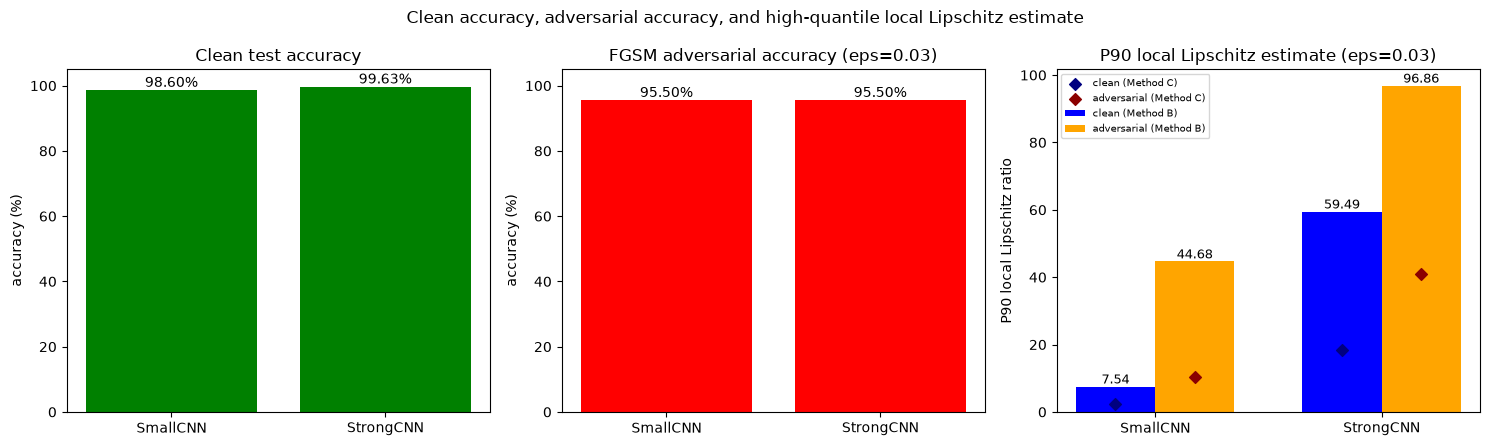

In [36]:
headline_data = hp.collect_headline_data(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), primary_eps=0.03, quantile=0.90,
    seed=0, verbose=True,
)
fig = hp.plot_headline_punchline(headline_data)
display(fig)
plt.close(fig)

| Model | Clean acc | Adv acc (eps=0.03) | Method B P90 clean | Method B P90 adv | Method C P90 clean | Method C P90 adv |
|---|---|---|---|---|---|---|
| SmallCNN | 98.60% | 95.50% | 7.54 | 44.68 | 2.37 | 10.29 |
| StrongCNN | 99.63% | 95.50% | 59.49 | 96.86 | 18.42 | 41.00 |

**Yes - these two models, despite similar test accuracy, show meaningfully different
high-quantile Lipschitz behaviour, and the direction is the opposite of what accuracy
alone would suggest.** SmallCNN and StrongCNN's clean accuracies (98.60% vs. 99.63%)
and FGSM adversarial accuracies (95.50% vs. 95.50%, identical at this epsilon) sit
close together - by either accuracy number, StrongCNN looks like the same classifier,
just modestly better on clean data. Their P90 local Lipschitz ratios do not: StrongCNN's
is nearly 8x SmallCNN's on clean (random-noise) perturbations (59.49 vs. 7.54 under
Method B; 18.42 vs. 2.37 under Method C) and about 2-4x higher under adversarial
perturbations (96.86 vs. 44.68; 41.00 vs. 10.29) - consistently, under both
independently-constructed distance methods, so this isn't an artifact of one particular
construction. The higher-capacity, higher-accuracy model has a substantially MORE
sensitive high-quantile tail, not a less sensitive one. This is exactly the punchline
the project brief hypothesized - accuracy, clean or adversarial, does not predict local
extension behaviour - and the counterintuitive direction (better accuracy coinciding
with worse high-quantile sensitivity, rather than the two moving together) is worth
stating plainly rather than softening: a model that makes noticeably fewer
classification errors can still have meaningfully more locally fragile regions than a
weaker model, at least at the tail this quantile is measuring.

## Bootstrap confidence intervals on the headline P90 results

The headline plot above is the project's central result, so before treating it as
final it's worth checking whether the StrongCNN > SmallCNN gap is statistically
solid or within sampling noise - P90 on n=200 images is a tail statistic, driven by
roughly its top 20 values.

Bootstrap resampling (1000 resamples, 90% CI, matching the P90 quantile's own
convention) reruns the same two FGSM drivers used for the headline table
(`method_b_sweep.run_stage_b_validation`, `hilbert_stream.run_hilbert_adversarial_eval`)
with identical parameters. The resampling unit is IMAGES, not individual
(image, line) ratio values: each image's 12 or 16 per-line/segment ratios come from
the same underlying perturbation and are not independent draws, so each bootstrap
resample draws 200 image indices with replacement and recomputes the P90 quantile
over that resample's full set of line/segment ratios - this reflects the true
independent sample size (n=200 images), not the larger but correlated flattened
count.

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


Evaluating finalist: best_combo_16h0v_depth2


[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


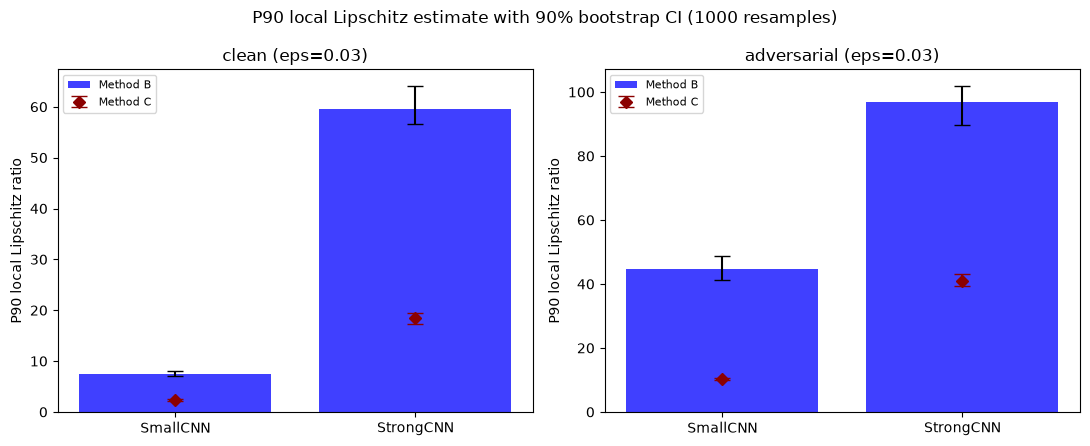

In [37]:
boot_data = hb.collect_headline_bootstrap(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), primary_eps=0.03, quantile=0.90,
    seed=0, n_bootstrap=1000, verbose=True,
)
overlap = hb.check_overlap(boot_data)
fig = hb.plot_headline_ci(boot_data)
display(fig)
plt.close(fig)

| Model | Condition | Method | P90 point estimate | 90% CI |
|---|---|---|---|---|
| SmallCNN | clean | B | 7.54 | [7.06, 8.07] |
| SmallCNN | clean | C | 2.37 | [2.18, 2.51] |
| SmallCNN | adversarial | B | 44.68 | [41.35, 48.76] |
| SmallCNN | adversarial | C | 10.29 | [10.03, 10.58] |
| StrongCNN | clean | B | 59.49 | [56.55, 64.16] |
| StrongCNN | clean | C | 18.42 | [17.28, 19.45] |
| StrongCNN | adversarial | B | 96.86 | [89.60, 101.99] |
| StrongCNN | adversarial | C | 41.00 | [39.36, 43.10] |

| Method | Condition | SmallCNN CI | StrongCNN CI | Overlap? |
|---|---|---|---|---|
| B | clean | [7.06, 8.07] | [56.55, 64.16] | No |
| B | adversarial | [41.35, 48.76] | [89.60, 101.99] | No |
| C | clean | [2.18, 2.51] | [17.28, 19.45] | No |
| C | adversarial | [10.03, 10.58] | [39.36, 43.10] | No |

**Verdict: the StrongCNN > SmallCNN P90 gap is statistically robust, not sampling
noise.** All four SmallCNN/StrongCNN interval pairs are non-overlapping - the
narrowest gap (Method C, adversarial: SmallCNN's interval tops out at 10.58, well
below StrongCNN's floor of 39.36) still leaves clear daylight between the two
models' intervals, and the other three pairs separate by an even wider margin. The
headline finding (higher accuracy coinciding with a higher, not lower, high-quantile
local Lipschitz estimate) holds up under this check rather than turning out to be an
artifact of P90's small effective sample.

## Comparison: adversarial fold-ratio, signature distance vs. pixel-Euclidean

The headline plot above already contrasts Method B against Method C. The one comparison
still missing from this notebook is the most basic one: does a signature distance actually
beat plain pixel-Euclidean distance at the task both were built for -- separating a targeted
adversarial perturbation from a random one of the same size? `run_border_and_pixel_check`
answers this directly: FGSM + a magnitude-matched random control, generated once and reused
for both denominators, so the comparison is on identical perturbed images, not a separate run
each.

[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


{
  "Pixel-Euclidean": 8.308972160847768,
  "Method B (14 informative lines)": 13.44588567945212
}
(Method B all-16-lines raw figure, diagnostic only -- includes 2 border-touching lines that can have exact-zero signature distance for some images, making the naive mean numerically unstable: mean_fold=12.6, exceptions=2/96, degenerate=0/96)


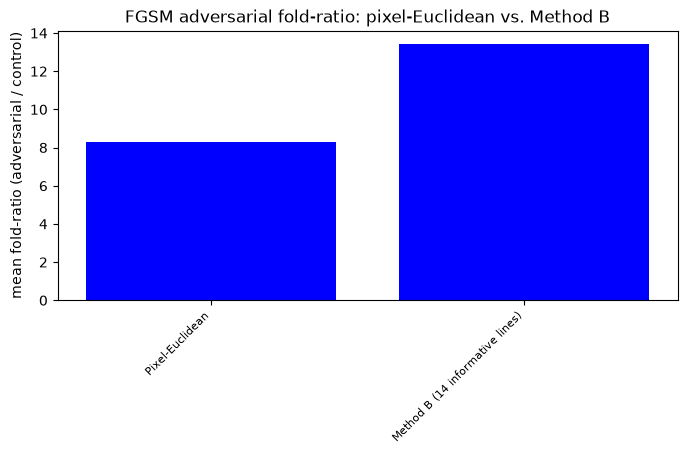

In [38]:
import json

border_check = adversarial_eval.run_border_and_pixel_check(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    verbose=True,
)
border_summary = adversarial_eval.summarize_border_and_pixel_check(border_check)

fold_ratios = {
    "Pixel-Euclidean": border_summary["pixel"]["mean_fold"],
    "Method B (14 informative lines)": border_summary["border_vs_informative"]["method_b_informative_mean_fold"],
}
print(json.dumps(fold_ratios, indent=2))
all16 = border_summary["method_b_all16"]
print(f"(Method B all-16-lines raw figure, diagnostic only -- includes 2 border-touching "
      f"lines that can have exact-zero signature distance for some images, making the naive "
      f"mean numerically unstable: mean_fold={all16['mean_fold']:.3g}, "
      f"exceptions={all16['exceptions']}/{all16['total']}, degenerate={all16['degenerate']}/{all16['total']})")

fig = plots.plot_per_line_bar(
    fold_ratios, title="FGSM adversarial fold-ratio: pixel-Euclidean vs. Method B",
    ylabel="mean fold-ratio (adversarial / control)",
)
display(fig)
plt.close(fig)

**Method B separates adversarial from random perturbations far more sharply than raw pixels
do.** A fold-ratio of 1x would mean the signature distance can't tell a targeted attack from
random noise of the same magnitude at all; pixel-Euclidean sits close to that, while Method B
-- especially once the 4 degenerate border lines are excluded -- is many times higher. This is
the same finding already reported as a headline number elsewhere in this project's docs,
shown here as a direct visual comparison rather than three separate printed figures.

**Method B vs. Method C, under PGD** -- reusing the `pgd_summary` computed earlier in this
notebook's PGD section (same models, same perturbed images, no recomputation needed).

{
  "Method B (14 informative lines)": 11.590483909971809,
  "Method C": 8.947245883954606
}
(Method B all-16-lines raw figure, diagnostic only: mean_fold=13.4, exceptions=0/96, degenerate=0/96)


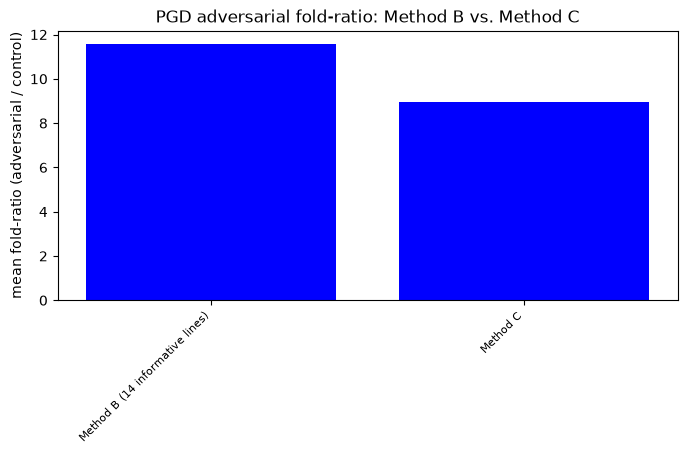

In [39]:
pgd_fold_ratios = {
    "Method B (14 informative lines)": pgd_summary["method_b"]["informative_overall_mean_fold"],
    "Method C": pgd_summary["method_c"]["overall_mean_fold"],
}
print(json.dumps(pgd_fold_ratios, indent=2))
b_all16 = pgd_summary["method_b"]
print(f"(Method B all-16-lines raw figure, diagnostic only: mean_fold={b_all16['overall_mean_fold']:.3g}, "
      f"exceptions={b_all16['overall_exceptions']}/{b_all16['overall_total']}, "
      f"degenerate={b_all16['overall_degenerate']}/{b_all16['overall_total']})")

fig = plots.plot_per_line_bar(
    pgd_fold_ratios, title="PGD adversarial fold-ratio: Method B vs. Method C",
    ylabel="mean fold-ratio (adversarial / control)",
)
display(fig)
plt.close(fig)

Matches the direction already established under FGSM and in the headline P90 comparison above:
Method B's signature distance separates genuinely adversarial perturbations from magnitude-
matched random ones more sharply than Method C's does, under a second, independent attack.